In [55]:
import pandas as pd
import numpy as np

In [56]:
df = pd.read_csv("powerplant_data.csv")

In [57]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [58]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [59]:
# AT - Temperature
# V - Vaccum
# AP - Pressure
# RH - Humidity

# PE - Produced Energy

In [60]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [61]:
# SPlit our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2, random_state = 42
)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
# converting data into tensors

import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [64]:
type(X_train_scaled)

numpy.ndarray

In [65]:
type(y_train)

pandas.core.series.Series

In [66]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32)

# Deep Learning

In [67]:
# Building our ANN model

class ANN(nn.Module):
    def __init__(self):

        #calling parent class(nn.Module) constructor
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            #o/p layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)

In [68]:
# X_train.shape -- tuple -- 0 idx : samples, 1 idx : i/p features

In [69]:
import torch.optim as optim
model = ANN()

#lass & optimizers
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [72]:
# Training the ANN

train_loss = []
val_loss = []
best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()

    # To calculate loss for each epoch
    running_loss = 0.0
    
    for xb,yb in train_loader:

        #xb - features of each batch
        #yb - labels of each batch

        # Zero_grad()--helps us no to accumalates grads of previous batch
        optimizer.zero_grad()

        # Forward propagation.. predicted o/p's for each batch
        outputs = model(xb)

        # Will compute loss
        loss = crietrion(outputs,yb)

        # Backward Propagation.. compute gradients
        loss.backward()

        # will update params
        optimizer.step()

        # loss is a tensor value, loss.item() will convert to python
        running_loss += loss.item()

    epoch_train_loss = running_loss/ len(train_loader)
    train_loss.append(epoch_train_loss)

    #evaluation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_loss.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training_loss = {epoch_train_loss}, validation_loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> training_loss = 19.37463385661443, validation_loss = 18.2460214138031
epoch 2/100 ==> training_loss = 19.498670609792075, validation_loss = 17.917407321929932
epoch 3/100 ==> training_loss = 19.37698516448339, validation_loss = 18.667484935124715
epoch 4/100 ==> training_loss = 19.300194430351258, validation_loss = 18.00472291310628
epoch 5/100 ==> training_loss = 19.32961669166883, validation_loss = 17.428093600273133
epoch 6/100 ==> training_loss = 19.460599774122237, validation_loss = 17.43883695602417
epoch 7/100 ==> training_loss = 19.481530690193175, validation_loss = 17.555901209513348
epoch 8/100 ==> training_loss = 19.374752523501716, validation_loss = 17.97237598101298
epoch 9/100 ==> training_loss = 19.396565119425457, validation_loss = 18.446738719940186
epoch 10/100 ==> training_loss = 19.59007062514623, validation_loss = 17.608698590596518
epoch 11/100 ==> training_loss = 19.45651412407557, validation_loss = 17.528515148162843
epoch 12/100 ==> training_los

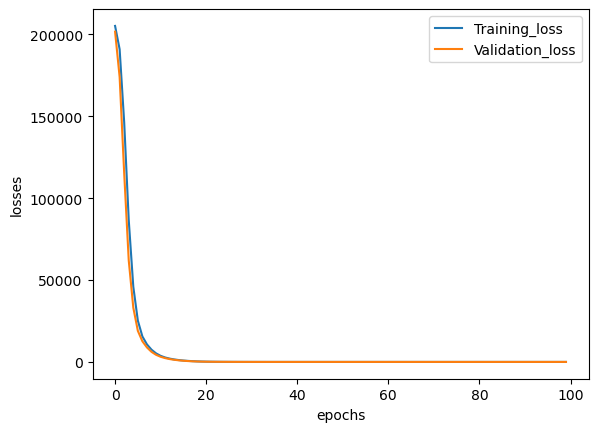

In [71]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "training_loss" : train_loss , 
    "validation_loss" : val_loss
    
})

#epochs = range(1,len(loss_df)+1)

plt.plot(loss_df["training_loss"], label="Training_loss")
plt.plot(loss_df["validation_loss"], label="Validation_loss")

plt.xlabel("epochs")
plt.ylabel("losses")

plt.legend()

In [73]:
#Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [76]:
# Evaluation

model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    #train_mse_loss = crietrion(y_train_tensor,train_preds)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE::",test_mse_loss.item())

Training MSE: 18.961042404174805
Testing MSE:: 17.403587341308594


In [78]:
from sklearn.metrics import r2_score

print("r2_score=", r2_score(y_test,test_preds))

r2_score= 0.9391789561232518


In [79]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["predicted_values"])
actual_df = pd.DataFrame(y_test.values, columns=["actual_values"])

pd.concat([predicted_df,actual_df], axis=1)

,predicted_values,actual_values
0,436.444611,433.27
1,435.549866,438.16
2,460.815582,458.42
3,477.036255,480.82
4,438.648071,441.41
...,...,...
1909,450.992767,456.70
1910,433.958191,438.04
1911,467.769440,467.80
1912,433.397186,437.14
